# ── Generate grouped main basin shapefile for Alexis ──

In [ ]:
# Imports

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
#
# Implements Alexis's 4-step workflow:
# Step 1: Find CAMELS polygons that contain at least one RGI glacier centroid
# Step 2: Filter by jerarquia to keep only highest-level basin per river system
# Step 3: (Visual check in QGIS/ArcGIS — do manually after export)
# Step 4: Compute basin area and glacier area, apply 1% minimum threshold
#
# Output: shapefile ready to share with Alexis for review

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
FILTRADO    = f'{BASE}/Camels_filtrado'
BOUNDS_PATH = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
RGI_PATH    = (f'{BASE}/files_chile_OGGM_climate_comparison/'
               f'RGI_BNA_Clusters.csv')
OUT_PATH    = f'{BASE}/Output/main_basins_for_alexis.shp'

GLAC_THRESHOLD_PCT = 1.0   # Alexis recommends 1% minimum glacier cover

# ── Load data ─────────────────────────────────────────────────────────────
print('Loading data...')
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
if bounds.crs.to_epsg() != 4326:
    bounds = bounds.to_crs(epsg=4326)

rgi = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

print(f'CAMELS polygons: {len(bounds)}')
print(f'RGI glaciers:    {len(gdf_rgi)}')

# ── Step 1: Find polygons containing at least one glacier centroid ─────────
print('\nStep 1: Spatial join — glacier centroids to basin polygons...')
joined = gpd.sjoin(gdf_rgi, bounds, how='inner', predicate='within')

glacierized_gauge_ids = set(joined['gauge_id'].unique())
print(f'Polygons containing at least one glacier: {len(glacierized_gauge_ids)}')

# Compute glacier area and count per polygon
glacier_stats = (joined.groupby('gauge_id')
                 .agg(n_glaciers  =('RGIId',   'count'),
                      glacier_area=('Area',     'sum'),
                      clusters    =('Cluster',  lambda x: list(x.unique())))
                 .reset_index())

# ── Step 2: Filter by jerarquia ────────────────────────────────────────────
print('\nStep 2: Loading jerarquia and filtering to main basins...')
hier = gpd.read_file(f'{FILTRADO}/Camels_jerarquia.shp')
hier['gauge_id'] = hier['gauge_id'].astype(str)
if hier.crs.to_epsg() != 4326:
    hier = hier.to_crs(epsg=4326)

print(f'Jerarquia unique values: {sorted(hier["jerarquia"].unique())}')
print(f'Total polygons in jerarquia shapefile: {len(hier)}')

# Keep only jerarquia=0 (main basins, no sub-sub-basins)
main_basins = hier[hier['jerarquia'] == 0].copy()
print(f'Main basins (jerarquia=0): {len(main_basins)}')

# Keep only those that contain glaciers
main_glacierized = main_basins[
    main_basins['gauge_id'].isin(glacierized_gauge_ids)].copy()
print(f'Main basins with glaciers: {len(main_glacierized)}')

# ── Step 4: Compute areas and apply 1% threshold ──────────────────────────
print('\nStep 4: Computing areas and applying glacier threshold...')

# Reproject to UTM for accurate area calculation
main_utm = main_glacierized.to_crs(epsg=32719)
main_utm['basin_area_km2'] = main_utm.geometry.area / 1e6

# Merge glacier stats
main_utm = main_utm.merge(glacier_stats, on='gauge_id', how='left')
main_utm['glacier_area_km2'] = main_utm['glacier_area'].fillna(0)
main_utm['glacier_pct']      = (main_utm['glacier_area_km2'] /
                                 main_utm['basin_area_km2'] * 100)

# Apply 1% threshold
before = len(main_utm)
main_final = main_utm[main_utm['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
after  = len(main_final)
print(f'Before 1% threshold: {before} basins')
print(f'After  1% threshold: {after} basins')
print(f'Removed: {before - after} basins below 1% glacier cover')

# ── Summary by cluster ─────────────────────────────────────────────────────
print('\nSummary:')
print(f'{"gauge_id":12s} {"n_glaciers":12s} {"basin_km2":12s} '
      f'{"glac_km2":10s} {"glac_pct":10s} {"clusters"}')
print('-' * 80)
for _, row in (main_final
               .sort_values('gauge_id')
               .iterrows()):
    print(f'{row["gauge_id"]:12s} {row["n_glaciers"]:12.0f} '
          f'{row["basin_area_km2"]:12.1f} '
          f'{row["glacier_area_km2"]:10.1f} '
          f'{row["glacier_pct"]:10.2f}% '
          f'{row["clusters"]}')

print(f'\nTotal basins for Alexis: {len(main_final)}')
print(f'Total glacier area:      {main_final["glacier_area_km2"].sum():.1f} km²')
print(f'Total basin area:        {main_final["basin_area_km2"].sum():.1f} km²')

# ── Export shapefile ───────────────────────────────────────────────────────
# Reproject back to WGS84 for sharing
main_export = main_final.to_crs(epsg=4326)

# Clean up columns for export
keep_cols = ['gauge_id', 'gauge_name', 'jerarquia',
             'n_glaciers', 'basin_area_km2',
             'glacier_area_km2', 'glacier_pct', 'geometry']
keep_cols = [c for c in keep_cols if c in main_export.columns]
main_export = main_export[keep_cols]

main_export.to_file(OUT_PATH)
print(f'\nSaved: {OUT_PATH}')
print('Ready to share with Alexis for Step 3 visual review.')

Loading data...
CAMELS polygons: 516
RGI glaciers:    13246

Step 1: Spatial join — glacier centroids to basin polygons...
Polygons containing at least one glacier: 266

Step 2: Loading jerarquia and filtering to main basins...
Jerarquia unique values: [0.0]
Total polygons in jerarquia shapefile: 146
Main basins (jerarquia=0): 146
Main basins with glaciers: 61

Step 4: Computing areas and applying glacier threshold...
Before 1% threshold: 61 basins
After  1% threshold: 24 basins
Removed: 37 basins below 1% glacier cover

Summary:
gauge_id     n_glaciers   basin_km2    glac_km2   glac_pct   clusters
--------------------------------------------------------------------------------
10523002              414       8851.6      229.1       2.59% ['WA2']
10704002              389       8682.4      128.6       1.48% ['WA2']
11040001              640      12429.1      325.4       2.62% ['WA2']
11130001               26        163.6       57.3      35.01% ['WA2']
11147001              175       5

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_63159/1408629889.py:126: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  main_export.to_file(OUT_PATH)
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'basin_area_km2' to 'basin_area'
  ogr_write(
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'glacier_area_km2' to 'glacier_ar'
  ogr_write(
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'glacier_pct' to 'glacier_pc'
  ogr_write(


Columns: ['gauge_id', 'gauge_name', 'jerarquia', 'n_glaciers', 'basin_area', 'glacier_ar', 'glacier_pc', 'geometry']

First few rows of cluster-related columns:
  gauge_id: ['3041005', '5707002', '5710001']
  gauge_name: ['Rio Lamas En El Salto', 'Rio Colorado Antes Junta Rio Maipo', 'Rio Maipo En El Manzano']
  jerarquia: [0.0, 0.0, 0.0]
  n_glaciers: [90, 92, 259]
  basin_area: [2271.847850075474, 1662.7976515094326, 4839.04678575912]
  glacier_ar: [28.403, 153.782, 350.65500000000003]
  glacier_pc: [1.250215765948253, 9.248389295017455, 7.246365152573977]

Cluster assignments:
    gauge_id cluster
0    3041005     DA1
1    5707002     DA2
2    5710001     DA3
3    5721001     DA2
4    5748001     DA3
5    6019003     DA3
6    6034001     DA3
7    6035001     DA3
8    9404001     WA1
9    9437002     WA1
10  10523002     WA2
11  10704002     WA2
12  11040001     WA2
13  11130001     WA2
14  11147001     WA2
15  11151001     WA2
16  11342001     WA2
17  11405001     WA2
18  11536004  

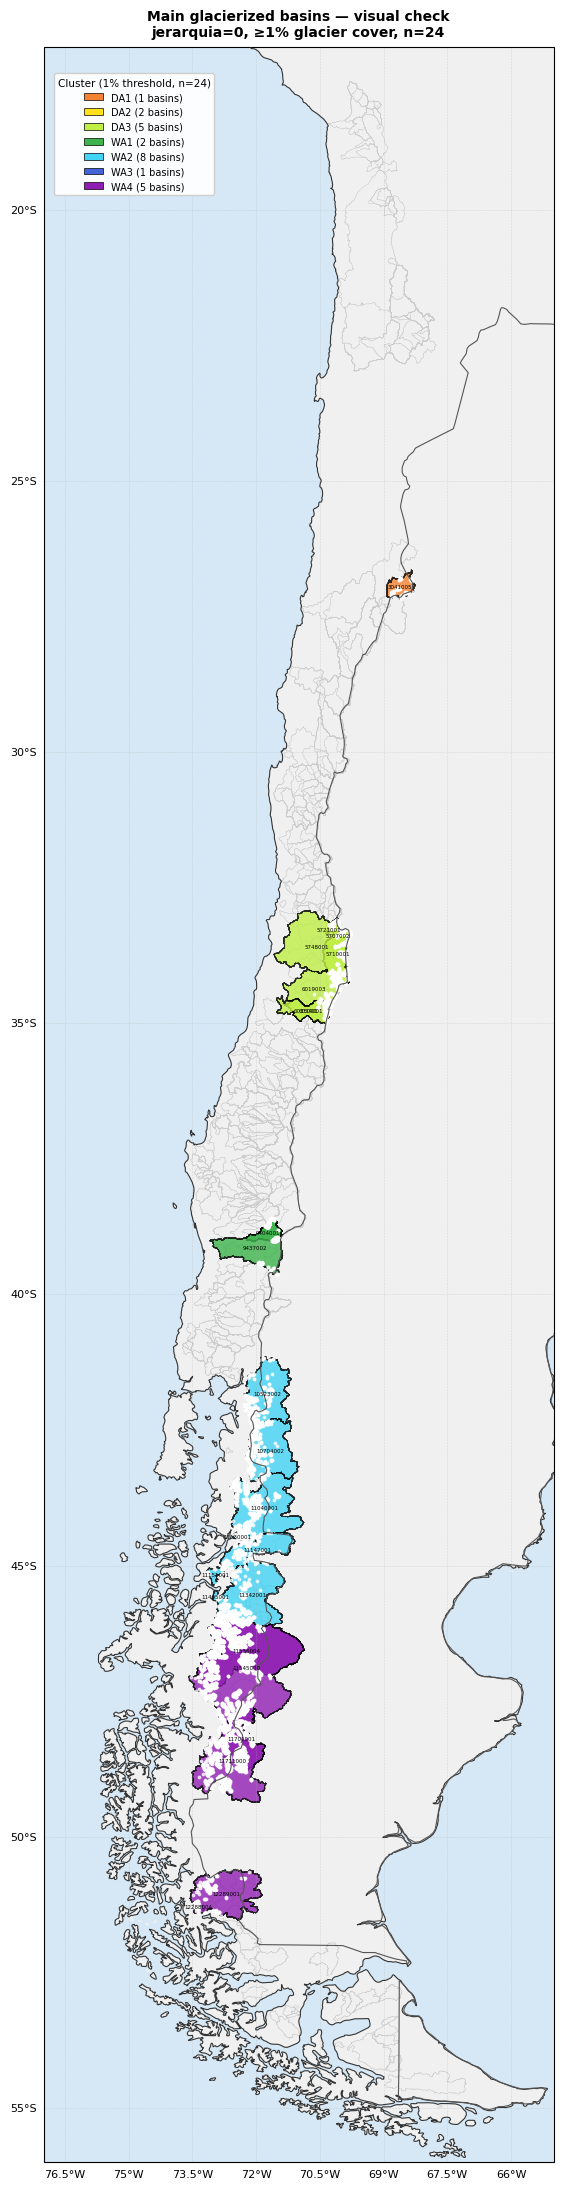

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/main_basins_visual_check.png


In [3]:
# ── Quick visual check of main_basins_for_alexis.shp ─────────────────────

BASE     = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'

# ── Load data ──────────────────────────────────────────────────────────────
main = gpd.read_file(f'{BASE}/Output/main_basins_for_alexis.shp')
if main.crs.to_epsg() != 4326:
    main = main.to_crs(epsg=4326)

# Debug: see what columns and values we actually have
print('Columns:', main.columns.tolist())
print('\nFirst few rows of cluster-related columns:')
for col in main.columns:
    if col != 'geometry':
        print(f'  {col}: {main[col].iloc[:3].tolist()}')

# Load all CAMELS boundaries for context
bounds_path = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
bounds = gpd.read_file(bounds_path).to_crs(epsg=4326)

# Load RGI glaciers
rgi = pd.read_csv(f'{BASE}/files_chile_OGGM_climate_comparison/'
                  f'RGI_BNA_Clusters.csv')
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

# ── Reassign cluster from RGI spatial join (more reliable than saved field) 
# Do a fresh spatial join to get cluster per basin
joined = gpd.sjoin(gdf_rgi[['RGIId','Cluster','geometry']],
                   main[['gauge_id','geometry']],
                   how='inner', predicate='within')

# Get dominant cluster per basin (most glaciers)
dominant_cluster = (joined.groupby('gauge_id')['Cluster']
                    .agg(lambda x: x.value_counts().index[0])
                    .reset_index()
                    .rename(columns={'Cluster': 'cluster'}))

main = main.merge(dominant_cluster, on='gauge_id', how='left')
print('\nCluster assignments:')
print(main[['gauge_id','cluster']].to_string())

# ── Cluster colors ─────────────────────────────────────────────────────────
cluster_colors = {
    'OT3': '#e6194b', 'DA1': '#f58231', 'DA2': '#ffe119',
    'DA3': '#bfef45', 'WA1': '#3cb44b', 'WA2': '#42d4f4',
    'WA3': '#4363d8', 'WA4': '#911eb4', 'WA5': '#f032e6',
    'WA6': '#01665e'
}
main['color'] = main['cluster'].map(cluster_colors).fillna('#cccccc')

# ── Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 22))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND,  facecolor='#f0f0f0', zorder=0)

# All CAMELS boundaries — light grey context
bounds.plot(ax=ax, facecolor='none', edgecolor='#cccccc',
            linewidth=0.3, zorder=1)

# Main basins colored by cluster — plot each separately
for cl, color in cluster_colors.items():
    subset = main[main['cluster'] == cl]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax,
                facecolor=color,
                edgecolor='k',
                linewidth=0.6,
                alpha=0.8,
                zorder=2)

# Any unassigned basins
unassigned = main[main['cluster'].isna()]
if len(unassigned):
    unassigned.plot(ax=ax, facecolor='#cccccc',
                    edgecolor='k', linewidth=0.4,
                    alpha=0.6, zorder=2)

# Glacier centroids inside main basins
glaciers_in = gpd.sjoin(gdf_rgi, main[['gauge_id','geometry']],
                         how='inner', predicate='within')
ax.scatter(glaciers_in.CenLon, glaciers_in.CenLat,
           s=3, c='white', alpha=0.7, zorder=3,
           transform=ccrs.PlateCarree())

# Coastline
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,
               edgecolor='#333333', zorder=4)

# Argentina border
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    world[world['NAME'] == 'Argentina'].plot(
        ax=ax, facecolor='none', edgecolor='#555555',
        linewidth=0.8, zorder=4,
        transform=ccrs.PlateCarree())
except Exception:
    pass

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  alpha=0.4, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Basin labels
for _, row in main.iterrows():
    centroid = row.geometry.centroid
    name = str(row.get('gauge_nam', row['gauge_id']))[:18]
    ax.text(centroid.x, centroid.y, name,
            fontsize=4, ha='center', va='center',
            color='k', zorder=5,
            transform=ccrs.PlateCarree())

# Legend
legend_handles = []
for cl in ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']:
    n = (main['cluster'] == cl).sum()
    if n == 0:
        continue
    legend_handles.append(mpatches.Patch(
        facecolor=cluster_colors[cl],
        edgecolor='k', linewidth=0.5,
        label=f'{cl} ({n} basins)'))

ax.legend(handles=legend_handles,
          loc='upper left',
          fontsize=7,
          framealpha=0.93,
          title=f'Cluster (1% threshold, n={len(main)})',
          title_fontsize=7.5,
          bbox_to_anchor=(0.01, 0.99))

ax.set_title(f'Main glacierized basins — visual check\n'
             f'jerarquia=0, ≥1% glacier cover, n={len(main)}',
             fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
out = f'{BASE}/Output/main_basins_visual_check.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## huh very few basins left... retrying with just a 0.5% glacier threshold instead of 1%:

Basins at 0.5% threshold: 35
    gauge_id cluster  glacier_pct  glacier_area_km2  basin_area_km2
17  10122001     WA1     0.695375            46.042     6621.175408
18  10503001     WA2     0.565431            20.296     3589.473585
19  10523002     WA2     2.588147           229.092     8851.585311
20  10704002     WA2     1.480661           128.557     8682.407745
21  11040001     WA2     2.618168           325.415    12429.108459
22  11130001     WA2    35.006026            57.284      163.640398
23  11147001     WA2     1.379132            71.057     5152.299407
24  11151001     WA2     4.408021            30.946      702.038323
25  11342001     WA2     1.277188           146.025    11433.321601
26  11405001     WA2     3.815468             6.579      172.429706
27  11536001     WA4     0.631582            32.104     5083.111542
28  11536004     WA4     6.532178          1097.390    16799.755269
29  11545000     WA4     6.843235          1875.978    27413.614617
30  11701001     WA

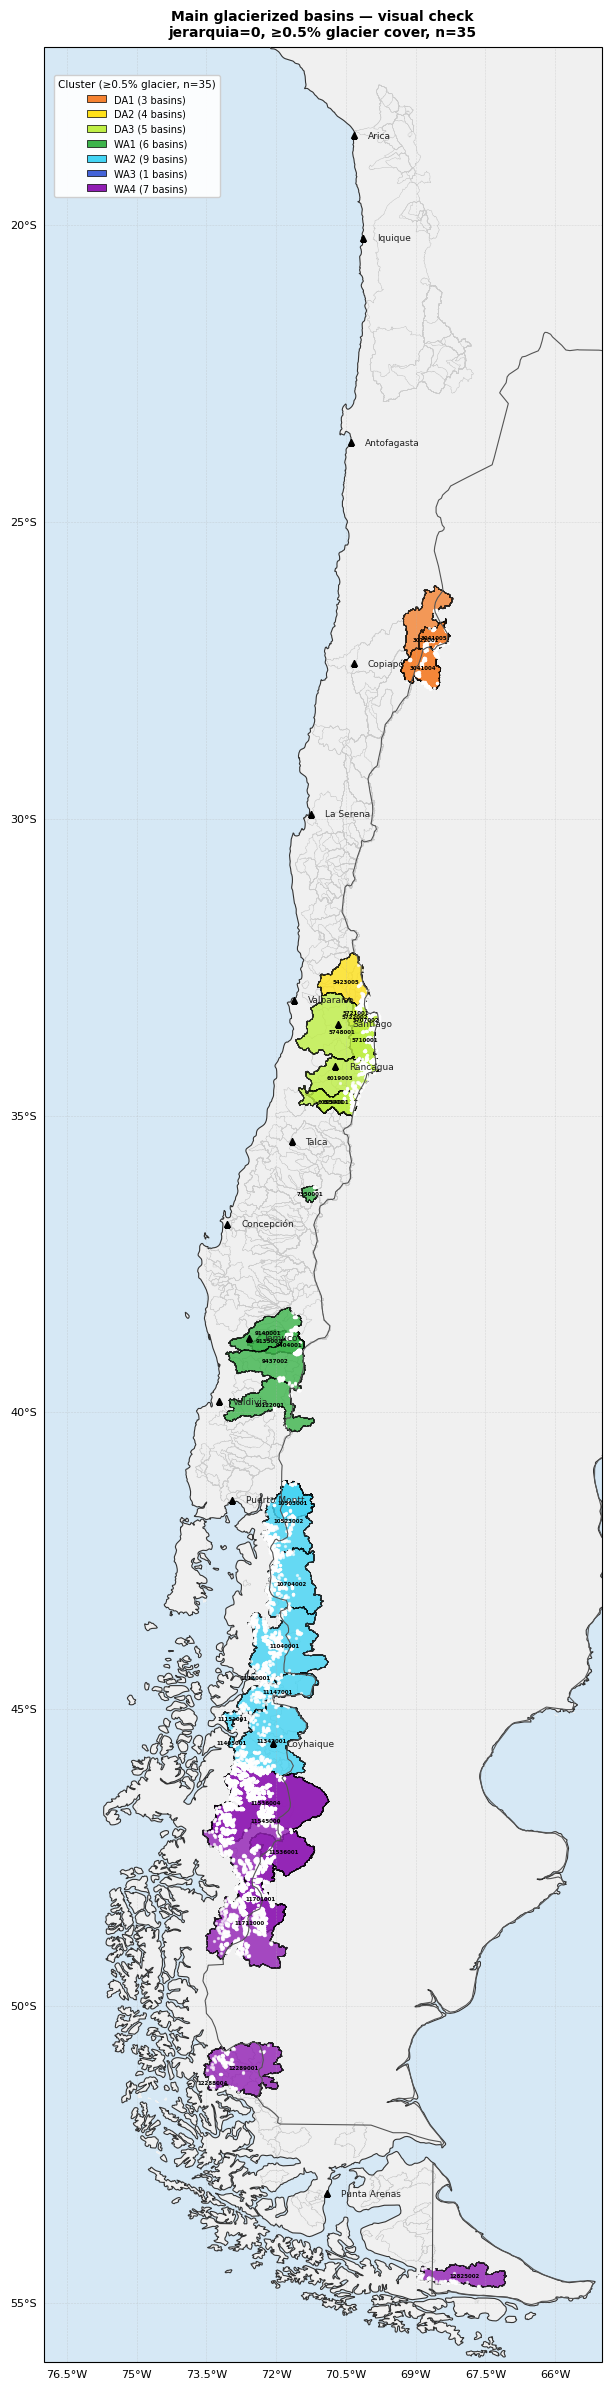

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/main_basins_visual_check_05pct.png


In [4]:
# ── Visual check with cities and 0.5% threshold ───────────────────────────

BASE     = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'

# ── Reload and recompute with 0.5% threshold ──────────────────────────────
FILTRADO    = f'{BASE}/Camels_filtrado'
BOUNDS_PATH = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
RGI_PATH    = (f'{BASE}/files_chile_OGGM_climate_comparison/'
               f'RGI_BNA_Clusters.csv')

GLAC_THRESHOLD_PCT = 0.5   # relaxed from 1.0%

bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
if bounds.crs.to_epsg() != 4326:
    bounds = bounds.to_crs(epsg=4326)

rgi = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

hier = gpd.read_file(f'{FILTRADO}/Camels_jerarquia.shp')
hier['gauge_id'] = hier['gauge_id'].astype(str)
if hier.crs.to_epsg() != 4326:
    hier = hier.to_crs(epsg=4326)

# Step 1: spatial join
joined = gpd.sjoin(gdf_rgi, bounds, how='inner', predicate='within')
glacierized_ids = set(joined['gauge_id'].unique())

glacier_stats = (joined.groupby('gauge_id')
                 .agg(n_glaciers=('RGIId',  'count'),
                      glacier_area=('Area',  'sum'))
                 .reset_index())

# Step 2: jerarquia=0 filter
main_basins = hier[hier['jerarquia'] == 0].copy()
main_glacierized = main_basins[
    main_basins['gauge_id'].isin(glacierized_ids)].copy()

# Step 4: compute areas and apply threshold
main_utm = main_glacierized.to_crs(epsg=32719).copy()
main_utm['basin_area_km2'] = main_utm.geometry.area / 1e6
main_utm = main_utm.merge(glacier_stats, on='gauge_id', how='left')
main_utm['glacier_area_km2'] = main_utm['glacier_area'].fillna(0)
main_utm['glacier_pct']      = (main_utm['glacier_area_km2'] /
                                 main_utm['basin_area_km2'] * 100)
main_final = main_utm[
    main_utm['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
main_final = main_final.to_crs(epsg=4326)

# Reassign cluster from fresh spatial join
joined2 = gpd.sjoin(gdf_rgi[['RGIId','Cluster','geometry']],
                    main_final[['gauge_id','geometry']],
                    how='inner', predicate='within')
dominant = (joined2.groupby('gauge_id')['Cluster']
            .agg(lambda x: x.value_counts().index[0])
            .reset_index()
            .rename(columns={'Cluster': 'cluster'}))
main_final = main_final.merge(dominant, on='gauge_id', how='left')

print(f'Basins at 0.5% threshold: {len(main_final)}')
print(main_final[['gauge_id','cluster','glacier_pct',
                   'glacier_area_km2','basin_area_km2']]
      .sort_values('gauge_id').to_string())

# ── Cluster colors ─────────────────────────────────────────────────────────
cluster_colors = {
    'OT3': '#e6194b', 'DA1': '#f58231', 'DA2': '#ffe119',
    'DA3': '#bfef45', 'WA1': '#3cb44b', 'WA2': '#42d4f4',
    'WA3': '#4363d8', 'WA4': '#911eb4', 'WA5': '#f032e6',
    'WA6': '#01665e'
}
main_final['color'] = (main_final['cluster']
                       .map(cluster_colors).fillna('#cccccc'))

# ── Key Chilean cities ─────────────────────────────────────────────────────
cities = {
    'Arica':        (-18.48, -70.32),
    'Iquique':      (-20.21, -70.14),
    'Antofagasta':  (-23.65, -70.40),
    'Copiapó':      (-27.37, -70.33),
    'La Serena':    (-29.91, -71.25),
    'Santiago':     (-33.45, -70.67),
    'Valparaíso':   (-33.05, -71.62),
    'Rancagua':     (-34.17, -70.74),
    'Talca':        (-35.43, -71.67),
    'Concepción':   (-36.82, -73.05),
    'Temuco':       (-38.74, -72.59),
    'Valdivia':     (-39.81, -73.24),
    'Puerto Montt': (-41.47, -72.94),
    'Coyhaique':    (-45.57, -72.07),
    'Punta Arenas': (-53.16, -70.91),
}

# ── Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 24))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND,  facecolor='#f0f0f0', zorder=0)

# All CAMELS boundaries — grey context
bounds.plot(ax=ax, facecolor='none', edgecolor='#cccccc',
            linewidth=0.3, zorder=1)

# Main basins colored by cluster
for cl, color in cluster_colors.items():
    subset = main_final[main_final['cluster'] == cl]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, facecolor=color, edgecolor='k',
                linewidth=0.6, alpha=0.8, zorder=2)

unassigned = main_final[main_final['cluster'].isna()]
if len(unassigned):
    unassigned.plot(ax=ax, facecolor='#cccccc', edgecolor='k',
                    linewidth=0.4, alpha=0.6, zorder=2)

# Glacier centroids inside main basins
glaciers_in = gpd.sjoin(gdf_rgi,
                         main_final[['gauge_id','geometry']],
                         how='inner', predicate='within')
ax.scatter(glaciers_in.CenLon, glaciers_in.CenLat,
           s=2, c='white', alpha=0.6, zorder=3,
           transform=ccrs.PlateCarree())

# Coastline and Argentina border
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,
               edgecolor='#333333', zorder=4)
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    world[world['NAME'] == 'Argentina'].plot(
        ax=ax, facecolor='none', edgecolor='#555555',
        linewidth=0.8, zorder=4,
        transform=ccrs.PlateCarree())
except Exception:
    pass

# Cities
for city, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'k^', markersize=5, zorder=6,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.3, lat, city, fontsize=6.5,
            va='center', color='#222222', zorder=6,
            transform=ccrs.PlateCarree())

# Basin labels
for _, row in main_final.iterrows():
    centroid = row.geometry.centroid
    gid = str(row['gauge_id'])
    ax.text(centroid.x, centroid.y, gid,
            fontsize=4, ha='center', va='center',
            color='k', fontweight='bold', zorder=5,
            transform=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  alpha=0.4, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Legend
legend_handles = []
for cl in ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']:
    n = (main_final['cluster'] == cl).sum()
    if n == 0:
        continue
    legend_handles.append(mpatches.Patch(
        facecolor=cluster_colors[cl], edgecolor='k',
        linewidth=0.5, label=f'{cl} ({n} basins)'))

ax.legend(handles=legend_handles, loc='upper left',
          fontsize=7, framealpha=0.93,
          title=f'Cluster (≥{GLAC_THRESHOLD_PCT}% glacier, n={len(main_final)})',
          title_fontsize=7.5,
          bbox_to_anchor=(0.01, 0.99))

ax.set_title(f'Main glacierized basins — visual check\n'
             f'jerarquia=0, ≥{GLAC_THRESHOLD_PCT}% glacier cover, '
             f'n={len(main_final)}',
             fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
out = f'{BASE}/Output/main_basins_visual_check_05pct.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')